In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

#Solving a Simple Boundary Value Problem
# Problem setup
L = 1  # Length of the domain
N = 10  # Number of elements
h = L / (N + 1)  # Element size

# Source term
f = np.ones(N)

# Assemble the system matrix
diagonals = [[-2] * N, [1] * (N - 1), [1] * (N - 1)]
A = diags(diagonals, [0, -1, 1]) / h**2

# Solve for u in Au = -f
u = spsolve(A, -f)

# Add boundary values (Dirichlet condition u(0) = u(1) = 0)
u = np.concatenate(([0], u, [0]))

# Plot the solution
x = np.linspace(0, L, N + 2)
plt.plot(x, u, 'o-', label='FEM Solution')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.title('Finite Element Solution')
plt.legend()
plt.show()

/opt/conda/lib/python3.8/site-packages/scipy/sparse/linalg/dsolve/linsolve.py:132: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  warn('spsolve requires A be CSC or CSR matrix format',


<Figure size 640x480 with 1 Axes>

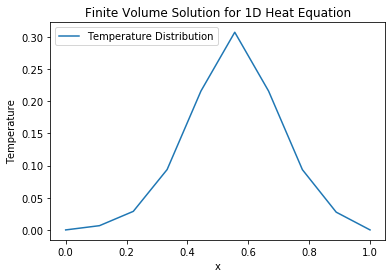

In [2]:
#Example: 1D Heat Equation (Conservastion of Heat)
# Parameters
alpha = 0.01  # Diffusion coefficient
dx = 0.1
dt = 0.01
L = 1.0
Nx = int(L / dx)
u = np.zeros(Nx)  # Initial temperature distribution
u[int(Nx/2)] = 1.0  # Initial heat at the center

# FVM discretization loop
for n in range(100):
    u_new = u.copy()
    for i in range(1, Nx - 1):
        u_new[i] = u[i] + alpha * dt / dx**2 * (u[i + 1] - 2 * u[i] + u[i - 1])
    u = u_new

# Plot the final temperature distribution
x = np.linspace(0, L, Nx)
plt.plot(x, u, label='Temperature Distribution')
plt.xlabel('x')
plt.ylabel('Temperature')
plt.title('Finite Volume Solution for 1D Heat Equation')
plt.legend()
plt.show()

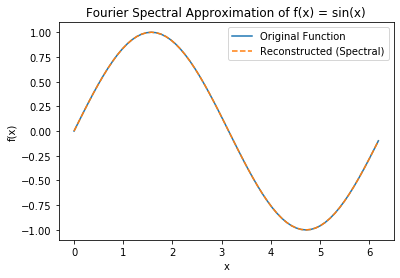

In [3]:
#Example: Fourier Spectral Method
from scipy.fftpack import fft, ifft
#After looking it up, scipy.ftt is a new version of scipy.fftpack not implemented

# Sample the function on a periodic domain
N = 64
x = np.linspace(0, 2 * np.pi, N, endpoint=False)
f = np.sin(x)

# Compute Fourier transform and reconstruct
f_hat = fft(f)
f_reconstructed = ifft(f_hat).real

# Plot the original and reconstructed function
plt.plot(x, f, label='Original Function')
plt.plot(x, f_reconstructed, '--', label='Reconstructed (Spectral)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Fourier Spectral Approximation of f(x) = sin(x)')
plt.legend()
plt.show()

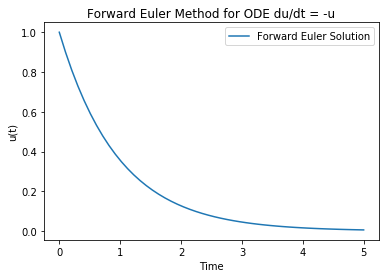

In [4]:
#Example: Forward Euler Method for ODE du/dt = -u
# Define parameters
T = 5.0  # Final time
dt = 0.1  # Time step
N = int(T / dt)
u = np.zeros(N)
u[0] = 1  # Initial condition

# Time-stepping loop
for n in range(1, N):
    u[n] = u[n-1] - dt * u[n-1]

#Plot the solution
t = np.linspace(0, T, N)
plt.plot(t, u, label='Forward Euler Solution')
plt.xlabel('Time')
plt.ylabel('u(t)')
plt.title('Forward Euler Method for ODE du/dt = -u')
plt.legend()
plt.show()

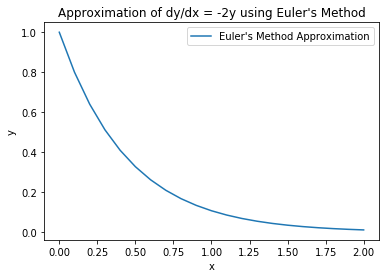

In [5]:
#Solving a Simple ODE using Finite Differences
# Define parameters
h = 0.1 # step size
x_start, x_end = 0, 2
num_steps = int((x_end - x_start) / h)

x_values = np.linspace(x_start, x_end, num_steps + 1)
y_values = np.zeros(num_steps + 1)

# Initial condition
y_values[0] = 1 # y(0) = 1

# Function representing dy/dx = -2y
def f(x, y):
    return -2 * y

# Implement Euler's method
for i in range(num_steps):
    y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])
    
# Plot the results
plt.plot(x_values, y_values, label="Euler's Method Approximation")
plt.xlabel('x')
plt.ylabel('y')
plt.title("Approximation of dy/dx = -2y using Euler's Method")
plt.legend()
plt.show()

Error for run #  1  : 0.0003589376858310518
Total Accumulated Error 0.0003589376858310518
Error for run #  2  : 0.0020073668823248243
Total Accumulated Error 0.002366304568155876
Error for run #  3  : 0.0032212981750991965
Total Accumulated Error 0.005587602743255073
Error for run #  4  : 0.004599896056662087
Total Accumulated Error 0.01018749879991716
Error for run #  5  : 0.005378649432156669
Total Accumulated Error 0.015566148232073829
Error for run #  6  : 0.00635990704128
Total Accumulated Error 0.02192605527335383
Error for run #  7  : 0.004912580415999993
Total Accumulated Error 0.026838635689353824
Error for run #  8  : 0.004425523199999995
Total Accumulated Error 0.03126415888935382
Error for run #  9  : 0.004782239999999995
Total Accumulated Error 0.03604639888935381
Error for run #  10  : 0.0004710399999999987
Total Accumulated Error 0.03651743888935381
Error for run #  11  : 0.0004080000000000011
Total Accumulated Error 0.03692543888935381
Error for run #  12  : 0.016128000

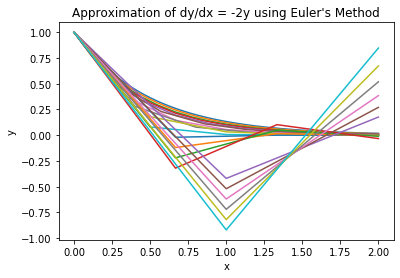

In [6]:
#In-Class Challenge 15
import numpy as np
import matplotlib.pyplot as plt

# Define parameters
h_values = np.arange(0.01, 1, 0.05)  # step size
x_start, x_end = 0, 2
error = 0
n = 0

for h in h_values:
    n += 1
    num_steps = int((x_end - x_start) / h)
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)

    # Initial condition
    y_values[0] = 1  # y(0) = 1
    # Function representing dy/dx = -2y
    def f(x, y):
        return -2 * y
    
    # Implement Euler's method
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])
        
        
    # Plot the results
    plt.plot(x_values, y_values)
    current =  np.abs(y_values[i+1] - y_values[i])
    error += current
    print(f"Error for run # ", n, " :", current)
    print(f"Total Accumulated Error", error)
    
        
        
plt.xlabel('x')
plt.ylabel('y')
plt.title("Approximation of dy/dx = -2y using Euler's Method")
plt.show()